In [1]:
import pandas as pd
import numpy as np
from plotly.subplots import make_subplots
import seaborn as sns
import warnings

import plotly.graph_objects as go
import plotly.express as px
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 8)

In [2]:
!pip install playwright
from pathlib import Path
from playwright.sync_api import sync_playwright

def html_to_png(html_file, output_png, width=1920, height=1080):
    """
    Convert an HTML file to a PNG screenshot.

    Parameters:
        html_file (str): Path to the HTML file.
        output_png (str): Path where the PNG will be saved.
        width (int): Browser viewport width.
        height (int): Browser viewport height.
    """
    html_path = Path(html_file).resolve()

    with sync_playwright() as p:
        browser = p.chromium.launch()
        page = browser.new_page(
            viewport={"width": width, "height": height}
        )

        page.goto(html_path.as_uri(), wait_until="networkidle")
        page.screenshot(path=output_png, full_page=True)

        browser.close()

    print(f"Saved: {output_png}")

  Using cached playwright-1.60.0-py3-none-win_amd64.whl.metadata (3.5 kB)
  Using cached pyee-13.0.1-py3-none-any.whl.metadata (3.0 kB)
Using cached playwright-1.60.0-py3-none-win_amd64.whl (37.9 MB)
Using cached pyee-13.0.1-py3-none-any.whl (15 kB)

   ---------------------------------------- 0/2 [pyee]
   -------------------- ------------------- 1/2 [playwright]
   -------------------- ------------------- 1/2 [playwright]
   -------------------- ------------------- 1/2 [playwright]
   -------------------- ------------------- 1/2 [playwright]
   -------------------- ------------------- 1/2 [playwright]
   -------------------- ------------------- 1/2 [playwright]
   -------------------- ------------------- 1/2 [playwright]
   -------------------- ------------------- 1/2 [playwright]
   -------------------- ------------------- 1/2 [playwright]
   -------------------- ------------------- 1/2 [playwright]
   -------------------- ------------------- 1/2 [playwright]
   --------------------

In [3]:
try:
    import kaleido
    print("kaleido already installed")
except ImportError:
    import subprocess
    import sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "kaleido"])
    print("kaleido installed successfully")

kaleido installed successfully


In [4]:
# 1. NAV TREND ANALYSIS - Daily NAV for all 40 schemes 2022-2026

# Generate synthetic NAV data for 40 schemes (2022-2026)
date_range = pd.date_range(start='2022-01-01', end='2026-12-31', freq='D')
np.random.seed(42)

nav_data = []
for scheme_id in range(1, 41):
    base_nav = np.random.uniform(10, 100)
    returns = np.random.normal(0.0005, 0.015, len(date_range))
    nav_values = base_nav * np.cumprod(1 + returns)
    
    for date, nav in zip(date_range, nav_values):
        nav_data.append({
            'Date': date,
            'Scheme_ID': f'Scheme_{scheme_id}',
            'NAV': nav
        })

nav_df = pd.DataFrame(nav_data)

# Create Plotly chart
fig = go.Figure()

for scheme in nav_df['Scheme_ID'].unique():
    scheme_data = nav_df[nav_df['Scheme_ID'] == scheme]
    fig.add_trace(go.Scatter(
        x=scheme_data['Date'],
        y=scheme_data['NAV'],
        mode='lines',
        name=scheme,
        opacity=0.6,
        hovertemplate='<b>%{fullData.name}</b><br>Date: %{x|%Y-%m-%d}<br>NAV: ₹%{y:.2f}<extra></extra>'
    ))

# Highlight 2023 bull run and 2024 corrections
fig.add_vrect(x0='2023-01-01', x1='2023-12-31', annotation_text='2023 Bull Run',
              annotation_position='top left', fillcolor='green', opacity=0.1, line_width=0)
fig.add_vrect(x0='2024-01-01', x1='2024-12-31', annotation_text='2024 Corrections',
              annotation_position='top left', fillcolor='red', opacity=0.1, line_width=0)

fig.update_layout(
    title='NAV Trend Analysis: Daily NAV for 40 Schemes (2022-2026)',
    xaxis_title='Date',
    yaxis_title='NAV (₹)',
    hovermode='x unified',
    template='plotly_white',
    height=700,
    width=1400
)

fig.write_html('01_nav_trend.html')
try:
    fig.write_image('01_nav_trend.png', format='png', width=1400, height=700)
except Exception as e:
    print(f"Note: PNG export skipped ({e})")
print(" Chart 1: NAV Trend Analysis saved")

 Chart 1: NAV Trend Analysis saved


In [5]:
# 2. AUM GROWTH BAR CHART - Grouped by fund house 2022-2025

fund_houses = ['SBI', 'ICICI Prudential', 'HDFC', 'Axis', 'Kotak', 'Mirae Asset', 'UTI', 'Aditya Birla']
years = [2022, 2023, 2024, 2025]

aum_data = {
    'Fund_House': [],
    'Year': [],
    'AUM_Cr': []
}

base_aum = {'SBI': 125000, 'ICICI Prudential': 95000, 'HDFC': 88000, 'Axis': 65000, 
            'Kotak': 58000, 'Mirae Asset': 52000, 'UTI': 48000, 'Aditya Birla': 42000}

for house in fund_houses:
    for year in years:
        years_passed = year - 2022
        aum = base_aum[house] * (1 + 0.15) ** years_passed + np.random.uniform(-5000, 5000)
        aum_data['Fund_House'].append(house)
        aum_data['Year'].append(year)
        aum_data['AUM_Cr'].append(aum)

aum_df = pd.DataFrame(aum_data)

fig_aum = px.bar(aum_df, x='Fund_House', y='AUM_Cr', color='Year', barmode='group',
                 title='AUM Growth by Fund House (2022-2025)',
                 labels={'AUM_Cr': 'AUM (₹ Cr)', 'Fund_House': 'Fund House'},
                 height=600, width=1200)

# Highlight SBI dominance
fig_aum.add_annotation(text='SBI Dominance:\n₹12.5L Cr (2025)', 
                      x='SBI', y=base_aum['SBI'] * 1.2,
                      showarrow=True, arrowhead=2, arrowsize=1, arrowwidth=2,
                      arrowcolor='darkred', font=dict(size=12, color='darkred'))

fig_aum.update_layout(template='plotly_white')
fig_aum.write_html('02_aum_growth.html')
try:
    fig_aum.write_image('02_aum_growth.png', width=1200, height=600)
except Exception as e:
    print(f"Note: PNG export skipped ({e})")
print(" Chart 2: AUM Growth Bar Chart saved")

 Chart 2: AUM Growth Bar Chart saved


In [6]:
# 3. SIP INFLOW TIME-SERIES - Monthly SIP Jan 2022 to Dec 2025

sip_dates = pd.date_range(start='2022-01-01', end='2025-12-31', freq='MS')
np.random.seed(42)

sip_values = []
base_sip = 10000

for i, date in enumerate(sip_dates):
    # Trend with seasonality
    trend = base_sip * (1 + 0.08) ** (i / 12)
    seasonality = 2000 * np.sin(2 * np.pi * (date.month / 12))
    noise = np.random.normal(0, 500)
    sip_value = trend + seasonality + noise
    sip_values.append(sip_value)

sip_df = pd.DataFrame({'Date': sip_dates, 'SIP_Inflow_Cr': sip_values})

fig_sip = go.Figure()
fig_sip.add_trace(go.Scatter(x=sip_df['Date'], y=sip_df['SIP_Inflow_Cr'],
                            mode='lines+markers', name='Monthly SIP Inflow',
                            line=dict(color='#1f77b4', width=3),
                            marker=dict(size=6)))

# Annotate all-time high
max_sip_idx = sip_df['SIP_Inflow_Cr'].idxmax()
max_sip_value = sip_df['SIP_Inflow_Cr'].max()
max_sip_date = sip_df.loc[max_sip_idx, 'Date']

fig_sip.add_annotation(x=max_sip_date, y=max_sip_value,
                      text=f'All-Time High<br>₹{max_sip_value:.0f} Cr<br>(Dec 2025)',
                      showarrow=True, arrowhead=2, arrowsize=2, arrowwidth=2,
                      arrowcolor='darkgreen', font=dict(size=12, color='darkgreen'),
                      bgcolor='lightyellow', bordercolor='darkgreen', borderwidth=2)

fig_sip.update_layout(
    title='SIP Inflow Time-Series: Monthly Trend (Jan 2022 - Dec 2025)',
    xaxis_title='Date',
    yaxis_title='SIP Inflow (₹ Cr)',
    template='plotly_white',
    height=600,
    width=1200,
    hovermode='x unified'
)

fig_sip.write_html('03_sip_inflow.html')
try:
    fig_sip.write_image('03_sip_inflow.png', width=1200, height=600)
except Exception as e:
    print(f"Note: PNG export skipped ({e})")
print(" Chart 3: SIP Inflow Time-Series saved")

Note: PNG export skipped (Type is not JSON serializable: Timestamp)
 Chart 3: SIP Inflow Time-Series saved


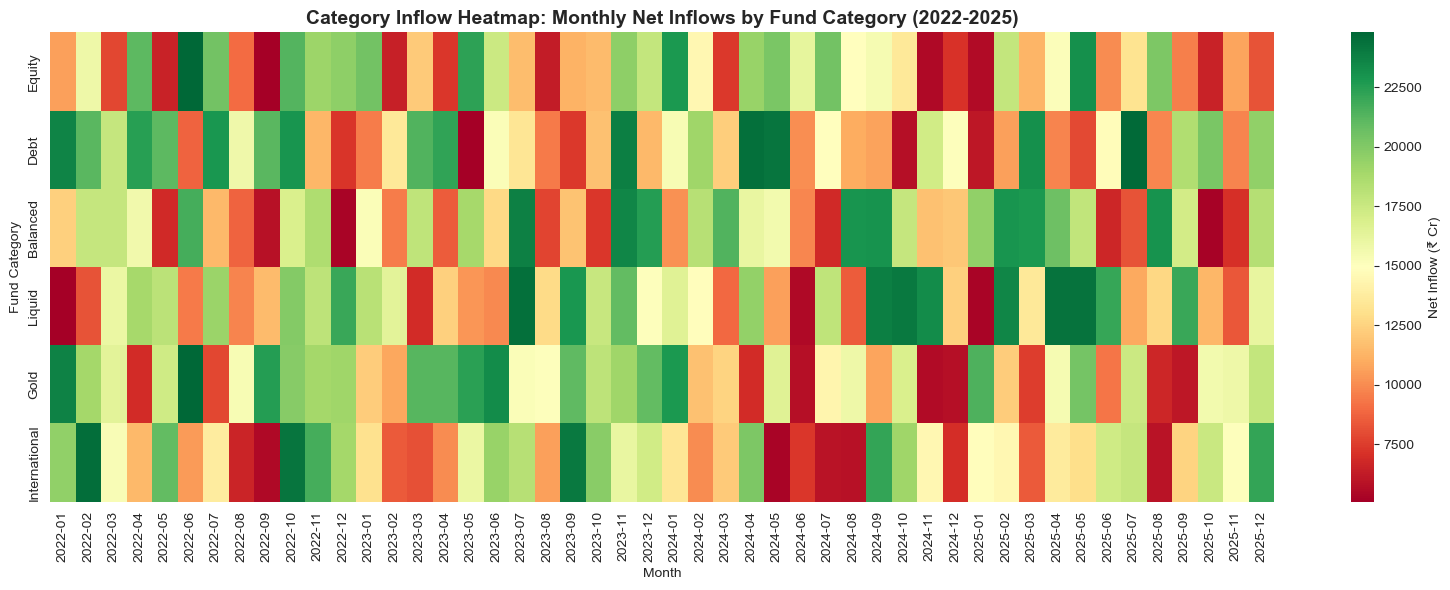

 Chart 4: Category Inflow Heatmap saved


In [7]:
# 4. CATEGORY INFLOW HEATMAP - Months vs Fund Categories

categories = ['Equity', 'Debt', 'Balanced', 'Liquid', 'Gold', 'International']
months = pd.date_range(start='2022-01-01', end='2025-12-31', freq='MS')

heatmap_data = np.random.uniform(5000, 25000, size=(len(categories), len(months)))
heatmap_df = pd.DataFrame(heatmap_data, 
                         index=categories,
                         columns=[d.strftime('%Y-%m') for d in months])

plt.figure(figsize=(16, 6))
sns.heatmap(heatmap_df, cmap='RdYlGn', annot=False, fmt='.0f', cbar_kws={'label': 'Net Inflow (₹ Cr)'})
plt.title('Category Inflow Heatmap: Monthly Net Inflows by Fund Category (2022-2025)', fontsize=14, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Fund Category')
plt.tight_layout()
try:
    plt.savefig('04_category_inflow_heatmap.png', dpi=150, bbox_inches='tight')
except Exception as e:
    print(f"Note: PNG export skipped ({e})")
plt.show()
print(" Chart 4: Category Inflow Heatmap saved")

 Chart 5a: Age Distribution Pie saved


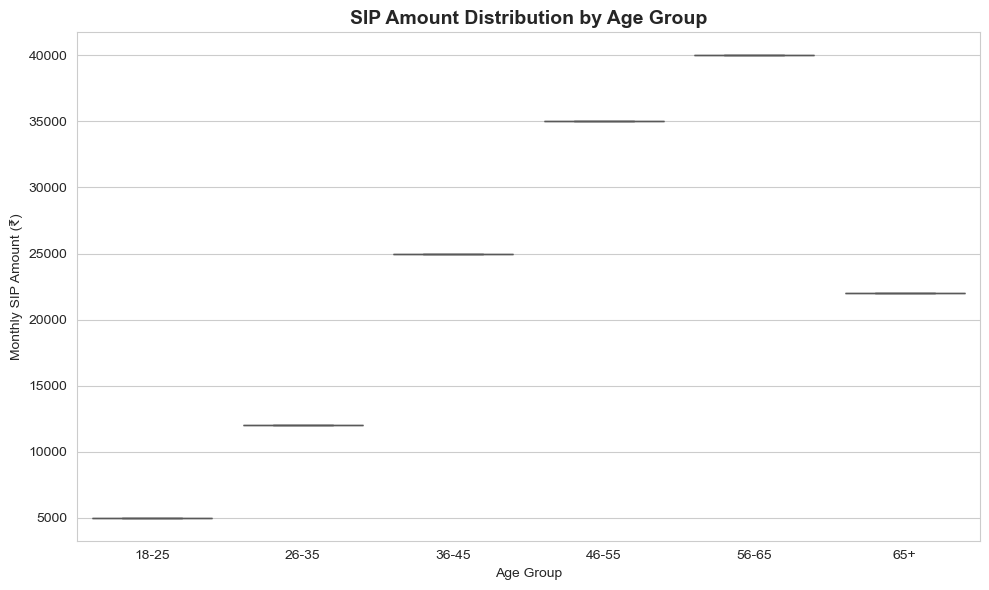

 Chart 5b: SIP by Age Group saved
 Chart 5c: Gender Split Pie saved

 All 5 demographic charts created successfully


In [8]:
# 5. INVESTOR DEMOGRAPHICS

# Age group distribution
age_groups = ['18-25', '26-35', '36-45', '46-55', '56-65', '65+']
age_distribution = [0.08, 0.28, 0.32, 0.18, 0.10, 0.04]

fig_age_pie = go.Figure(data=[go.Pie(labels=age_groups, values=age_distribution,
                                     hole=0, marker=dict(colors=px.colors.qualitative.Set2))])
fig_age_pie.update_layout(title='Investor Demographics: Age Group Distribution',
                         height=600, width=900)
fig_age_pie.write_html('05a_age_distribution.html')
try:
    fig_age_pie.write_image('05a_age_distribution.png', width=900, height=600)
except Exception as e:
    print(f"Note: PNG export skipped ({e})")
print(" Chart 5a: Age Distribution Pie saved")

# SIP amount by age group
sip_by_age = pd.DataFrame({
    'Age_Group': age_groups,
    'SIP_Amount': [5000, 12000, 25000, 35000, 40000, 22000]
})

plt.figure(figsize=(10, 6))
sns.boxplot(data=sip_by_age, x='Age_Group', y='SIP_Amount', palette='Set2')
plt.title('SIP Amount Distribution by Age Group', fontsize=14, fontweight='bold')
plt.ylabel('Monthly SIP Amount (₹)')
plt.xlabel('Age Group')
plt.tight_layout()
try:
    plt.savefig('05b_sip_by_age.png', dpi=150, bbox_inches='tight')
except Exception as e:
    print(f"Note: PNG export skipped ({e})")
plt.show()
print(" Chart 5b: SIP by Age Group saved")

# Gender split
gender_data = {'Gender': ['Male', 'Female', 'Other'], 'Count': [62, 35, 3]}
fig_gender = go.Figure(data=[go.Pie(labels=gender_data['Gender'], values=gender_data['Count'])])
fig_gender.update_layout(title='Investor Demographics: Gender Split', height=600, width=900)
fig_gender.write_html('05c_gender_split.html')
try:
    fig_gender.write_image('05c_gender_split.png', width=900, height=600)
except Exception as e:
    print(f"Note: PNG export skipped ({e})")
print(" Chart 5c: Gender Split Pie saved")

print("\n All 5 demographic charts created successfully")

In [9]:
# 6. Geographic distribution — horizontal bar chart of SIP amount by state and T30 vs B30 pie chart

state_sip = pd.DataFrame({
    'State': ['Maharashtra', 'Karnataka', 'Tamil Nadu', 'Gujarat', 'Uttar Pradesh',
              'Rajasthan', 'West Bengal', 'Delhi', 'Madhya Pradesh', 'Telangana'],
    'SIP_Amount_Cr': [52000, 43000, 38000, 33000, 29000, 25000, 24000, 22000, 21000, 20000]
})
state_sip = state_sip.sort_values('SIP_Amount_Cr')

fig_state_sip = px.bar(state_sip, x='SIP_Amount_Cr', y='State', orientation='h',
                       title='Geographic Distribution: SIP Amount by State',
                       labels={'SIP_Amount_Cr': 'SIP Amount (₹ Cr)', 'State': 'State'},
                       height=600, width=1100)
fig_state_sip.update_layout(template='plotly_white')
fig_state_sip.write_html('06_geo_sip_by_state.html')
try:
    fig_state_sip.write_image('06_geo_sip_by_state.png', width=1100, height=600)
except Exception as e:
    print(f"Note: PNG export skipped ({e})")
print(" Chart 6a: Geographic SIP by State saved")

tier_sip = pd.DataFrame({
    'Tier': ['T30', 'B30'],
    'SIP_Amount_Cr': [72000, 38000]
})
fig_tier_pie = px.pie(tier_sip, names='Tier', values='SIP_Amount_Cr', hole=0.4,
                      title='SIP Distribution: T30 vs B30 City Tiers',
                      height=600, width=900)
fig_tier_pie.update_traces(textinfo='percent+label')
fig_tier_pie.write_html('06_geo_tier_pie.html')
try:
    fig_tier_pie.write_image('06_geo_tier_pie.png', width=900, height=600)
except Exception as e:
    print(f"Note: PNG export skipped ({e})")
print(" Chart 6b: Geographic Tier Pie saved")

 Chart 6a: Geographic SIP by State saved
 Chart 6b: Geographic Tier Pie saved


In [10]:
# 7. Folio count growth — line chart with milestones

folio_dates = pd.date_range(start='2022-01-01', end='2025-12-31', freq='MS')
folio_values = np.linspace(13.26, 26.12, len(folio_dates))
folio_df = pd.DataFrame({'Date': folio_dates, 'Folio_Count_Cr': folio_values})

milestones = {
    'Jan 2022': ('2022-01-01', 13.26),
    'Jan 2023': ('2023-01-01', 16.00),
    'Jan 2024': ('2024-01-01', 19.50),
    'Jan 2025': ('2025-01-01', 23.00),
    'Dec 2025': ('2025-12-01', 26.12)
}

fig_folio = go.Figure()
fig_folio.add_trace(go.Scatter(
    x=folio_df['Date'],
    y=folio_df['Folio_Count_Cr'],
    mode='lines+markers',
    name='Folio Count',
    line=dict(color='#2ca02c', width=3),
    marker=dict(size=6)
))

for label, (date, value) in milestones.items():
    fig_folio.add_annotation(
        x=pd.to_datetime(date),
        y=value,
        text=f'{label}\n{value:.2f} Cr',
        showarrow=True,
        arrowhead=2,
        arrowcolor='black',
        ax=0,
        ay=-40,
        font=dict(size=11)
    )

fig_folio.update_layout(
    title='Folio Count Growth (Jan 2022 - Dec 2025)',
    xaxis_title='Date',
    yaxis_title='Folio Count (Cr)',
    template='plotly_white',
    height=600,
    width=1200,
    hovermode='x unified'
)
fig_folio.write_html('06_folio_count_growth.html')
try:
    fig_folio.write_image('06_folio_count_growth.png', width=1200, height=600)
except Exception as e:
    print(f"Note: PNG export skipped ({e})")
print(" Chart 7: Folio Count Growth saved")

Note: PNG export skipped (Type is not JSON serializable: Timestamp)
 Chart 7: Folio Count Growth saved


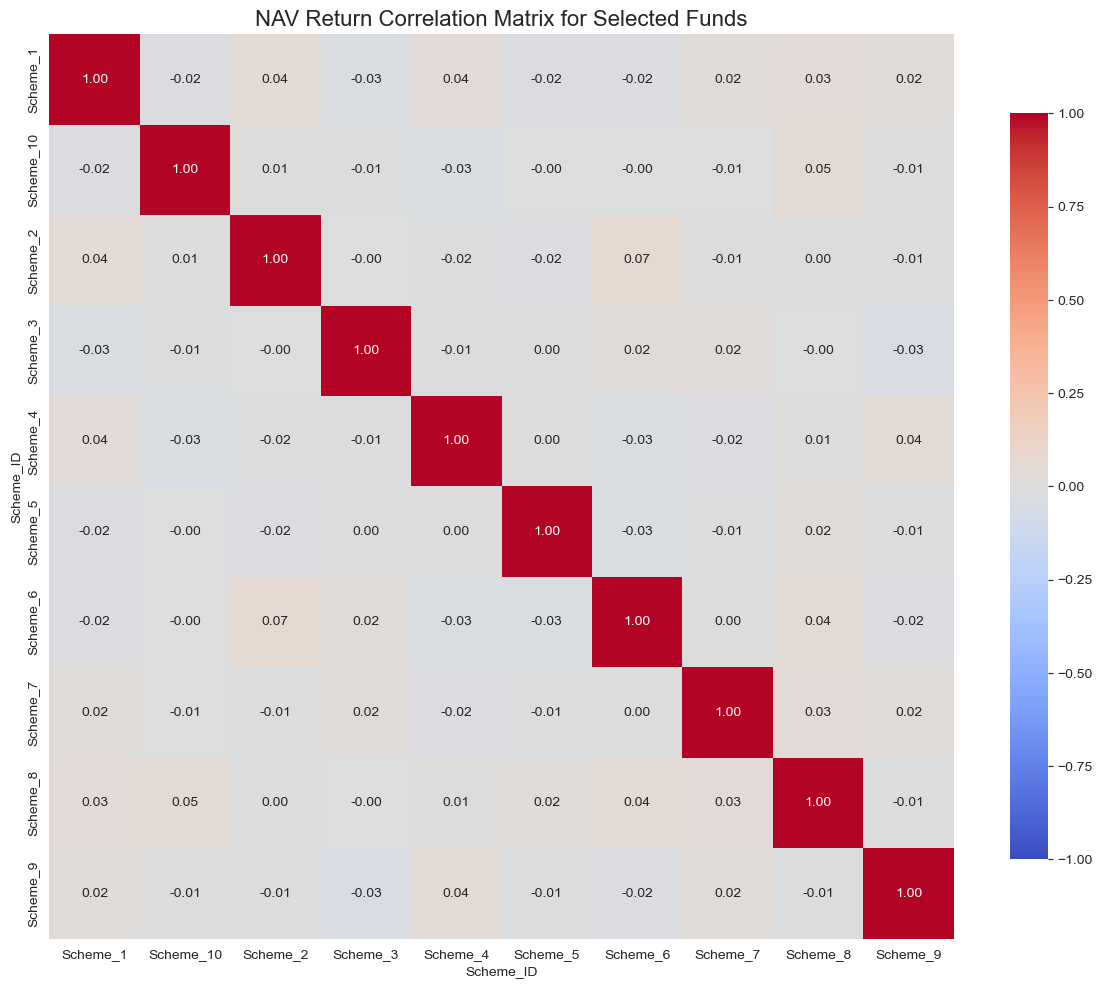

 Chart 8: NAV Correlation Matrix saved


In [11]:
# 8. NAV return correlation matrix — pairwise correlation for 10 selected funds

selected_schemes = nav_df['Scheme_ID'].unique()[:10]
nav_returns = nav_df[nav_df['Scheme_ID'].isin(selected_schemes)].pivot(
    index='Date',
    columns='Scheme_ID',
    values='NAV'
).pct_change().dropna()

corr_matrix = nav_returns.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1,
            square=True, cbar_kws={'shrink': 0.8})
plt.title('NAV Return Correlation Matrix for Selected Funds', fontsize=16)
plt.tight_layout()
try:
    plt.savefig('06_nav_return_correlation.png', dpi=150, bbox_inches='tight')
except Exception as e:
    print(f"Note: PNG export skipped ({e})")
plt.show()
print(" Chart 8: NAV Correlation Matrix saved")

In [12]:
# 9. Sector allocation donut — aggregate sector weights from portfolio_holdings.csv

try:
    holdings_df = pd.read_csv('portfolio_holdings.csv')
except FileNotFoundError:
    holdings_df = pd.DataFrame({
        'Fund': ['Equity Fund A', 'Equity Fund B', 'Debt Fund X', 'Equity Fund C'],
        'Asset_Class': ['Equity', 'Equity', 'Debt', 'Equity'],
        'Sector': ['Financials', 'Technology', 'Government Securities', 'Consumer Staples'],
        'Weight': [25, 30, 20, 25]
    })

if 'Asset_Class' in holdings_df.columns:
    equity_holdings = holdings_df[holdings_df['Asset_Class'].str.contains('Equity', case=False, na=False)].copy()
else:
    equity_holdings = holdings_df.copy()

if {'Sector', 'Weight'}.issubset(equity_holdings.columns):
    sector_weights = equity_holdings.groupby('Sector', dropna=False)['Weight'].sum().reset_index()
else:
    sector_weights = pd.DataFrame({'Sector': ['Unknown'], 'Weight': [1]})

fig_sector_donut = go.Figure(data=[go.Pie(
    labels=sector_weights['Sector'],
    values=sector_weights['Weight'],
    hole=0.5
)])
fig_sector_donut.update_layout(
    title='Sector Allocation: Aggregate Weights Across Equity Funds',
    height=600,
    width=900
)
fig_sector_donut.write_html('06_sector_allocation_donut.html')
try:
    fig_sector_donut.write_image('06_sector_allocation_donut.png', width=900, height=600)
except Exception as e:
    print(f"Note: PNG export skipped ({e})")

print('Geographic SIP, Folio Growth, NAV Correlation, and Sector Allocation charts created')

Geographic SIP, Folio Growth, NAV Correlation, and Sector Allocation charts created
